# Sentinel-2 Cloud Masking

The Level‑2A product includes cloud detection via the Sen2Cor scene classification layer (SCL), but known limitations remain, particularly for cloud shadows ([Tarrio et al., 2020](https://doi.org/10.1016/j.srs.2020.100010)). The sensor‑agnostic deep learning model OmniCloudMask ([Wright et al., 2025](https://doi.org/10.1016/j.rse.2025.114694)), available as open‑source Python software, operates directly on Level‑2A data and thus avoids additional downloads.

____

While the data extraction scripts shown in this repository show an overview of the extraction pipeline for a short time period of one site, the extended analysis requires a full year of one sits to be fully downloaded. The helper script `download_Sentinel_2` ensures all data is downloaded. The helper script is entirely based on the demonstraction script in `data_extraction/data_extraction.ipynb`.

**Note:** the script takes about an hour to run, depending on connection speeds. The script will skip any downloads which are already complete.

In [1]:
from download_Sentinel_2 import get_download

In [2]:
msds = get_download()

Dataset identifier,Status,Message,Exception
DE-RuS/sen2,COMPLETED,Dataset 'DE-RuS/sen2' already generated.,-


In [3]:
msds.display_config()

User-defined ID,Data Store ID,Data Store Params,Data ID,Open Data Params,Grid-Mapping,Format
DE-RuS/sen2,stac-pc-ardc,-,sentinel-2-l2a,"time_range: ['2018-01-01', '2018-12-31']; point: [6.4471, 50.8659]; bbox_width: 4000; spatial_res: 10; asset_names: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12', 'SCL']",-,Zarr


In [4]:
msds.display_geolocations()

In [5]:
import pathlib
import numpy as np
import xarray as xr
import dask.array as da
import matplotlib.pyplot as pl
from matplotlib import colors

from omnicloudmask import predict_from_array

import cloud_mask_utils as cmutils

OmniCloudMask requires only three input bands (red, green, and near‑infrared) and minimal implementation effort. The classification yields four classes: 0 (Clear), 1 (Thick Cloud), 2 (Thin Cloud), and 3 (Cloud Shadow).

In [6]:
ds = xr.open_zarr("../data/DE-RuS/sen2.zarr/")
ds = ds[["SCL", "B04", "B03", "B08", "B02"]].compute()
ds

<xarray.Dataset> Size: 273MB
Dimensions:      (time: 71, y: 400, x: 400)
Coordinates:
  * time         (time) datetime64[ns] 568B 2018-01-03T10:44:29.027000 ... 20...
  * y            (y) float64 3kB 5.643e+06 5.643e+06 ... 5.639e+06 5.639e+06
  * x            (x) float64 3kB 7.406e+05 7.406e+05 ... 7.445e+05 7.445e+05
    spatial_ref  int64 8B 0
Data variables:
    SCL          (time, y, x) float64 91MB 9.0 9.0 9.0 9.0 ... 9.0 9.0 9.0 9.0
    B04          (time, y, x) float32 45MB 0.7196 0.7164 0.708 ... 0.6544 0.652
    B03          (time, y, x) float32 45MB 0.7464 0.7452 0.7396 ... 0.668 0.6532
    B08          (time, y, x) float32 45MB 0.7472 0.7452 ... 0.7208 0.7036
    B02          (time, y, x) float32 45MB 0.8304 0.8216 ... 0.7148 0.7104
Attributes:
    stac_catalog_url:    https://planetarycomputer.microsoft.com/api/stac/v1
    xcube_stac_version:  1.3.1

This initial analysis focuses on the scaled wide dynamic range vegetation index (sWDRVI).

In [7]:
def calc_sWDRVI(ds):
    return (0.1 * ds["B08"] - ds["B04"]) / (0.1 * ds["B08"] + ds["B04"])

ds["sWDRVI"] = calc_sWDRVI(ds)

Most of the code for generating the cloud mask is in the `cloud_mask_utils.py` script. In the next cell, we generate the mask and, applying a buffer around cloud and shadow classes to account for edge uncertainty. 

In [8]:
ds, cmask = cmutils.generate_cloud_mask(ds=ds)

[generate_cloud_mask] auto chunk_time from target_mb=50 MiB → 27


/home/data/home/Packages/eo-lincs-scs1/.pixi/envs/default/lib/python3.13/site-packages/omnicloudmask/cloud_mask.py:274: UserWarning: Patch size too large, reducing to 400 and overlap to 200.
  patch_overlap, patch_size = check_patch_size(


In [9]:
ds_masked, keep_mask, stats, timings = cmutils.burn_buffered_cloud_mask(
    ds,
    var_of_interest=("sWDRVI", "B04","B03","B02"),
    keep_values=(0, 3),
    buffer_pixels=2
)

ds["buffered_mask"] = keep_mask.rename("buffered_mask")

mask built in 0.10s | applied to 4 var(s) in 0.23s | total 0.32s
Original bad: 6,660,349 | Buffered bad: 6,852,846 | Extra masked by buffer: 192,497


As a demonstration of the cloud mask, we focus on one partially cloudy day. First we ganerate a true-colour composite of the Sentinel-2 Level-2A image.

In [10]:
time = "2018-06-02"
ds_day = ds.sel(time=time).squeeze("time")
origin = "upper"

Text(0.5, 1.0, 'true-colour composite')

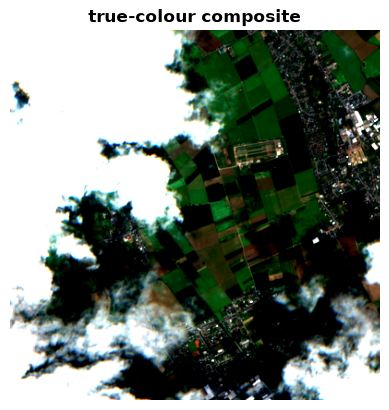

In [11]:
channels=("B04","B03","B02")
rgb = np.stack([ds_day[ch].values for ch in channels], axis=-1).astype("float32")

percentiles = (30, 70)
vmin, vmax = np.nanpercentile(rgb, percentiles)
rgb = np.clip((rgb - vmin) / (vmax - vmin), 0, 1)

pl.imshow(rgb, origin=origin)
pl.gca().set_axis_off()
pl.title("true-colour composite", fontweight="bold")

Now, as a baseline, we can look at the original SCL classifications from the Sentinel 2 L2A product.

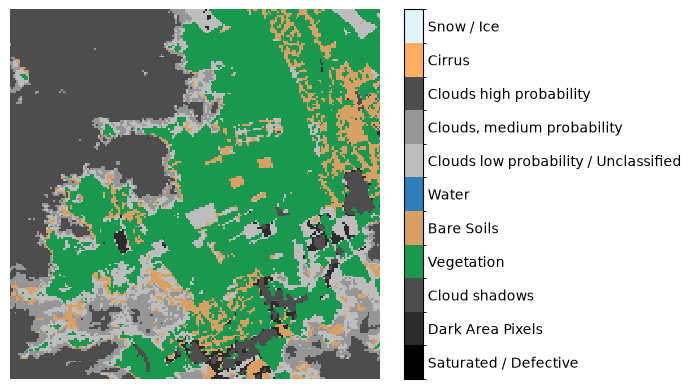

In [12]:
scl_colors = {
    1: '#000000', # Saturated / Defective
    2: '#2b2b2b', # Dark Area Pixels
    3: '#4d4d4d', # Cloud shadows
    4: '#1a9850', # Vegetation
    5: '#d9a066', # Bare Soils
    6: '#2c7fb8', # Water
    7: '#bdbdbd', # Clouds low probability / Unclassified
    8: '#969696', # Clouds, medium probability
    9: '#4d4d4d', # Clouds high probability
    10: '#fdae61', # Cirrus
    11: '#e0f3f8', # Snow / Ice
}

scl_names = {
    # 0: 'No Data',
    1: 'Saturated / Defective',
    2: 'Dark Area Pixels',
    3: 'Cloud shadows',
    4: 'Vegetation',
    5: 'Bare Soils',
    6: 'Water',
    7: 'Clouds low probability / Unclassified',
    8: 'Clouds, medium probability',
    9: 'Clouds high probability',
    10: 'Cirrus',
    11: 'Snow / Ice',   
}

classes = np.array(list(scl_colors.keys()))
bounds = np.zeros(len(scl_colors)+1)
bounds[:-1] = classes-0.5
bounds[1:] = classes+0.5

fig, ax = pl.subplots(1,1,)

# make a color map of fixed colors
cmap = colors.ListedColormap(list(scl_colors.values()))
norm = colors.BoundaryNorm(bounds, cmap.N)

# tell imshow about color map so that only set colors are used
img = ax.imshow(ds_day.SCL, interpolation='nearest', origin=origin,
                    cmap=cmap, norm=norm)
pl.gca().set_axis_off()



# make a color bar
cbar = pl.colorbar(img, cmap=cmap, norm=norm, boundaries=bounds)#, ticks=list(scl_names.keys())[::-1])
# add tick labels to colorbar
cbar.set_ticks(list(scl_names.keys())[::-1], labels=list(scl_names.values())[::-1])
cbar.ax.tick_params(length=0)          # remove tick lines


We then convert the SCL classifications into the OmniCloudMask simplified 4 classifications, and compare them.

In [13]:
csl2omni = {
    0: [4, 5, 6, 11, ],
    1: [7, 8, 9],
    2: [10, ],
    3: [3, 2, 1],
}

i=1
scl_mapped = ds_day["SCL"]*0 -1
for i in csl2omni:
    scl_mapped = xr.where(ds_day["SCL"].isin(csl2omni[i]),
        i, scl_mapped,
    )

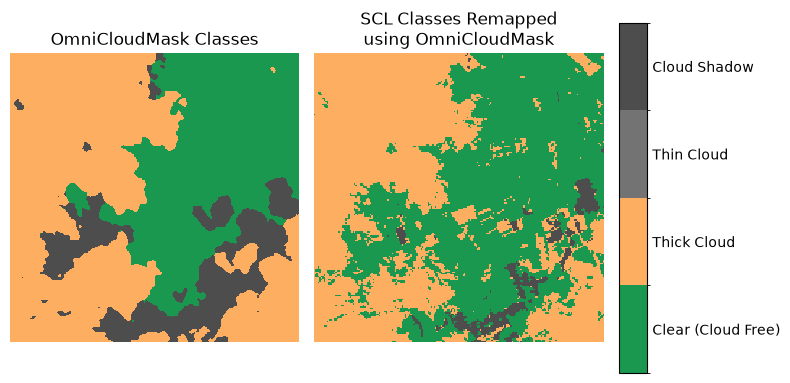

In [14]:
scl_colors = {
    0: '#1a9850', # Saturated / Defective
    1: '#fdae61', # Dark Area Pixels
    2: '#737373', # Cloud shadows
    3: '#4d4d4d', # Vegetation
}

scl_names = {
    0: 'Clear (Cloud Free)',
    1: 'Thick Cloud',
    2: 'Thin Cloud',
    3: 'Cloud Shadow',
}

classes = np.array(list(scl_colors.keys()))
bounds = np.zeros(len(scl_colors)+1)
bounds[:-1] = classes-0.5
bounds[1:] = classes+0.5


gridspec = {'width_ratios': [1, 1, 0.1]}
fig, axs = pl.subplots(1, 3, figsize=(8, 4), gridspec_kw=gridspec)



# make a color map of fixed colors
cmap = colors.ListedColormap(list(scl_colors.values()))
norm = colors.BoundaryNorm(bounds, cmap.N)

# tell imshow about color map so that only set colors are used
img = axs[0].imshow(ds_day.cloud_mask, interpolation='nearest', origin=origin,
                    cmap=cmap, norm=norm)
axs[0].set_axis_off()
axs[0].set_title("OmniCloudMask Classes")


# tell imshow about color map so that only set colors are used
img = axs[1].imshow(scl_mapped, interpolation='nearest', origin=origin,
                    cmap=cmap, norm=norm)
axs[1].set_axis_off()
axs[1].set_title("SCL Classes Remapped\nusing OmniCloudMask")


# make a color bar
cbar = pl.colorbar(img, cax=axs[-1], cmap=cmap, norm=norm, boundaries=bounds)
# add tick labels to colorbar
cbar.set_ticks(list(scl_names.keys())[::-1], labels=list(scl_names.values())[::-1])
cbar.ax.tick_params(length=0)          # remove tick lines


fig.tight_layout()

In an initial visual assessment, OmniCloudMask performed better than the Sen2Cor SCL. We can also see the difference between the two.

Text(0.5, 1.0, 'Difference = OmniCloudMask - SCL remapped')

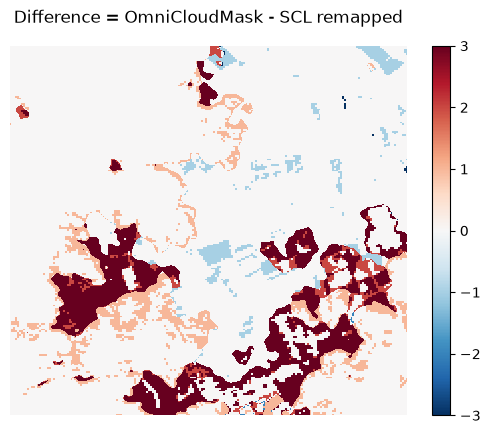

In [19]:
(ds_day.cloud_mask - scl_mapped).plot()
pl.gca().set_axis_off()
pl.title("Difference = OmniCloudMask - SCL remapped")

Although the cloud mask successfully excludes most cloud-contaminated pixels while retaining shadowed areas, its performance is imperfect and may occasionally lead to underclassification of clouds. A spatial buffer of 7 pixels was therefore applied to reduce residual cloud contamination. Because buffering is intentionally kept conservative to avoid excessive loss of valid observations, a trade-off arises between minimising residual cloud remnants and preventing over-buffering. While stronger buffering reduces cloud artefacts, it may also remove valid pixels, whereas limited buffering preserves valid data but can leave small patches of invalid pixels.

Assuming that scenes acquired under sufficient illumination conditions exhibit adequate radiometric contrast, they are expected to show a relatively high spatial standard deviation. In contrast, heavily cloud- or shadow-contaminated scenes typically exhibit reduced contrast and therefore low scene-level standard deviation. Partially contaminated scenes may still retain high spatial variability in unaffected areas and thus maintain higher standard deviation values.



Text(0.5, 1.0, 'true-colour composite\nwithout contrast enhancement')

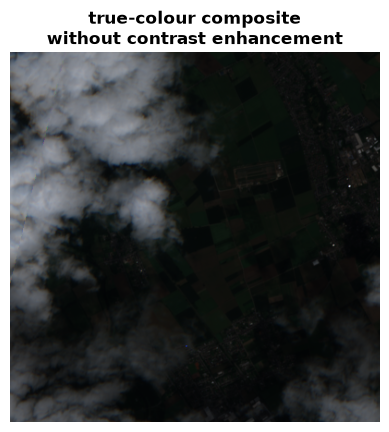

In [16]:
channels=("B04","B03","B02")
rgb = np.stack([ds_day[ch].values for ch in channels], axis=-1).astype("float32")

percentiles = (0, 100)
vmin, vmax = np.nanpercentile(rgb, percentiles)
rgb = np.clip((rgb - vmin) / (vmax - vmin), 0, 1)

pl.imshow(rgb, origin=origin)
pl.gca().set_axis_off()
pl.title("true-colour composite\nwithout contrast enhancement", fontweight="bold")

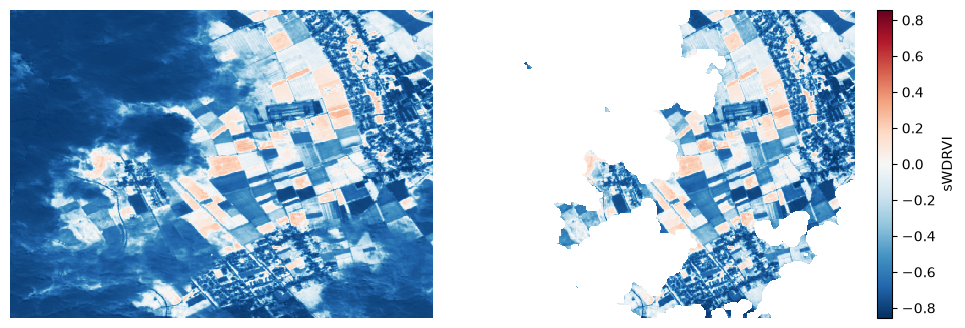

In [17]:
fig, axs = pl.subplots(1, 2, figsize=(12,4))

ds_day.sWDRVI.plot(ax=axs[0], add_colorbar=False)
ds_day.sWDRVI.where(ds_day.buffered_mask).plot(ax=axs[1])
for ax in axs:
    ax.set_axis_off()
    ax.set_title(None)

Based on these assumptions, several scenarios may occur after cloud masking. First, an entirely cloud-covered scene may be preserved due to underclassification, resulting in nearly 100% valid pixels but unusually low scene standard deviation. Second, residual cloud patches may remain when buffering is insufficient; such scenes are typically characterised by < 90% valid pixels combined with low standard deviation. Third, scenes with low reported cloud cover (e.g., ~10%) may still contain localised contamination and are characterised by < 90% valid pixels but relatively high standard deviation due to sufficient illumination and preserved image contrast. Scenes identified as invalid under these conditions need to be excluded from the time series.

Therefore, scenes with a low fraction of valid pixels (e.g., ~10%) and low spatial standard deviation are considered unreliable, whereas scenes with ~100% valid pixels but low spatial variability may also indicate underclassified cloud contamination, except in structurally homogeneous areas. Building on these assumptions, a heuristic scene-quality metric (score) based on valid-pixel fraction and spatial standard deviation was introduced to detect and remove invalid observations from the time series. 

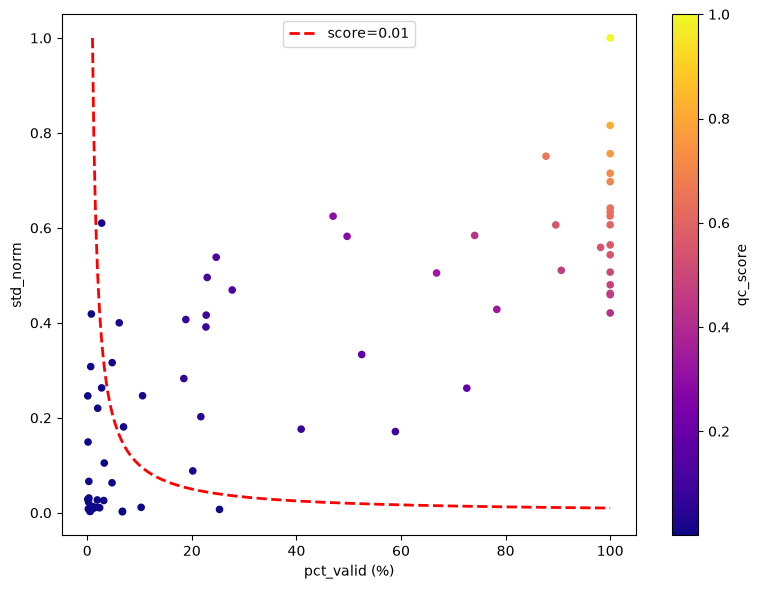

In [18]:
def compute_valid_pixel_fraction(da):
    """
    computes  scene completeness / data availability

    percentage of valid pixels within scene

    pct  = percentage
    valid = valid pixels (not masked, not cloud, not NaN)
    """
    valid = da.notnull()

    n_valid = valid.sum(dim=("y", "x"))
    n_total = valid.count(dim=("y", "x"))

    # mask denominator BEFORE division to prevents 0/0
    pct_valid = (n_valid / n_total.where(n_total > 0)) * 100.0

    pct_valid.name = "pct_valid"
    pct_valid.attrs["long_name"] = "Valid pixel percentage"
    pct_valid.attrs["units"] = "%"
    return pct_valid


def compute_std_t_safe(da):
    """
    computes spatial standard deviation per time step

    safe version:
    - skip NaNs
    - no divide-by-zero warnings
    - returns NaN if no valid pixels exist
    """

    dims_spatial = ("y", "x")

    # number of valid pixels
    cnt = da.count(dim=dims_spatial).astype("float32")

    # mask denominator BEFORE division
    denom = cnt.where(cnt > 0)

    # mean
    mean = da.sum(dim=dims_spatial, skipna=True).astype("float32") / denom

    # variance
    var = ((da - mean) ** 2).sum(dim=dims_spatial, skipna=True).astype("float32") / denom

    std_t = np.sqrt(var)

    std_t.name = "std_t"
    std_t.attrs["long_name"] = "Spatial standard deviation"
    return std_t






da = ds.sWDRVI.where(ds.buffered_mask)
dims_spatial = ("y", "x")
SCORE_THRESHOLD = 0.01


pct_valid = compute_valid_pixel_fraction(da)
std_t = compute_std_t_safe(da)
std_max = std_t.max(skipna=True)
std_norm = std_t / std_max.where((std_max > 0) & np.isfinite(std_max))

score = ((pct_valid / 100.0) * std_norm).rename("qc_score")


pct_vals = pct_valid.values
std_norm_vals = std_norm.values
score_vals = score.values



# --- plot
fig, ax = pl.subplots(figsize=(8,6))

sc = ax.scatter(
    pct_vals,
    std_norm,
    c=score_vals,
    cmap="plasma",
    s=20
)

x = np.linspace(1.0, 100.0, 400, dtype=float)

y = SCORE_THRESHOLD / (x / 100.0)

# keep only visible values
mask = np.isfinite(y) & (y <= 1.0)
ax.plot(x[mask], y[mask], "r--", lw=2, label=f"score={SCORE_THRESHOLD}")

# --- styling
ax.set_xlabel("pct_valid (%)")
ax.set_ylabel("std_norm")
#ax.set_xlim(0, 100)
#ax.set_ylim(0, 1)

pl.colorbar(sc, ax=ax, label="qc_score")
ax.legend()

pl.tight_layout()
